# STAT-654 Project Report
## Performance Analysis of Ensemble Methods for Hotel Booking Cancellation Prediction

**Authors:** Sai Nithin Reddy Maddi, Sujith Julakanti  
**Date:** March 2026

---

### Abstract

In this project, we analyze the **Hotel Booking Demand** dataset (~120,000 records) and formulate a binary classification task to predict booking cancellations.  
We implement and systematically compare:
- **Logistic Regression** (baseline statistical model)
- **Decision Tree** (single-tree baseline)
- **Random Forest** (bagging ensemble)
- **Gradient Boosting** (boosting ensemble)

Hyperparameter tuning is performed via stratified `GridSearchCV`. Models are evaluated on accuracy, precision, recall, F1-score, ROC-AUC, and computational efficiency.

**Dataset:** [Kaggle — Hotel Booking Demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

---
## 0. Imports & Configuration

In [1]:
import time, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics        import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

warnings.filterwarnings('ignore')
np.random.seed(42)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# ── Config ────────────────────────────────────────────────────
DATA_FILE   = 'hotel_bookings.csv'
OUTPUT_DIR  = 'figures'
SAMPLE_SIZE = None   # set to e.g. 50_000 to speed up; None = full data
TEST_SIZE   = 0.20
CV_FOLDS    = 5
N_JOBS      = -1

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


---
## 1. Data Loading

Download `hotel_bookings.csv` from [Kaggle](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand) and place it in the same directory as this notebook.

In [2]:
df = pd.read_csv(DATA_FILE)
if SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print(f'Shape          : {df.shape}')
print(f'Cancellation % : {df["is_canceled"].mean():.2%}')
df.head()

Shape          : (119390, 32)
Cancellation % : 37.04%


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Basic statistics
df.describe(include='all').T.head(30)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


In [4]:
print('Missing values per column (top 10):')
df.isnull().sum().sort_values(ascending=False).head(10)

Missing values per column (top 10):


company                   112593
agent                      16340
country                      488
children                       4
reserved_room_type             0
assigned_room_type             0
booking_changes                0
deposit_type                   0
hotel                          0
previous_cancellations         0
dtype: int64

---
## 2. Exploratory Data Analysis (EDA)

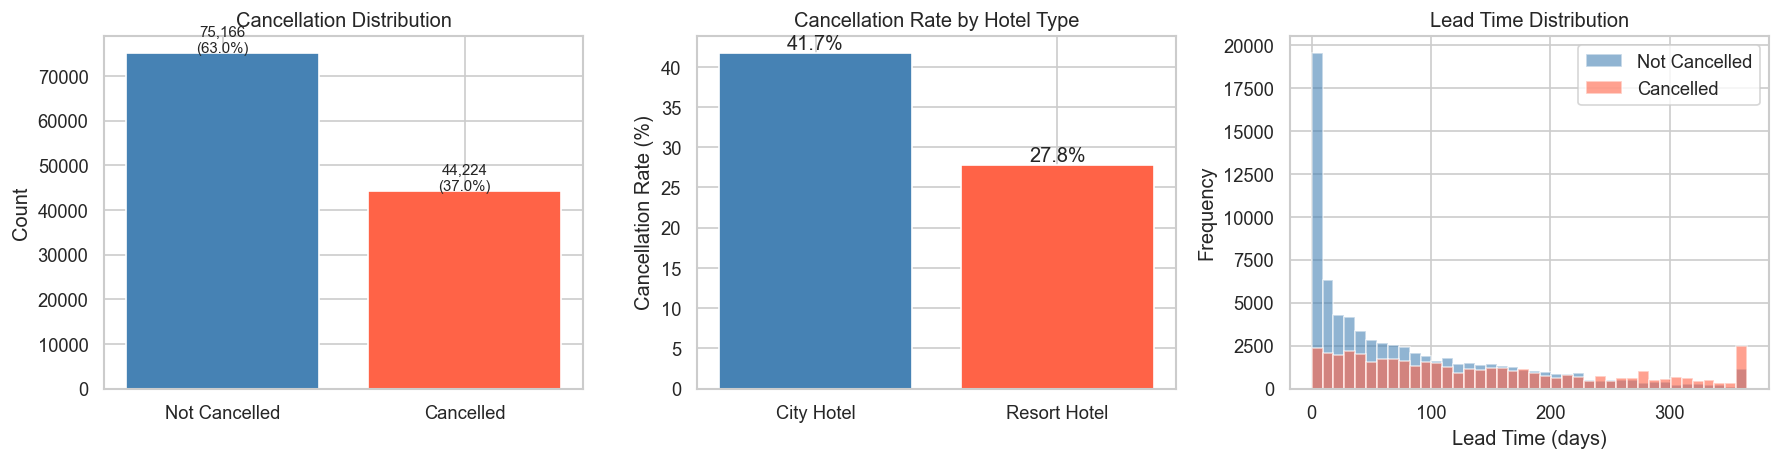

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Target distribution
cancel_counts = df['is_canceled'].value_counts()
axes[0].bar(['Not Cancelled','Cancelled'], cancel_counts.values,
            color=['steelblue','tomato'], edgecolor='white')
axes[0].set_title('Cancellation Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(cancel_counts.values):
    axes[0].text(i, v+200, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=9)

# By hotel type
hotel_cancel = df.groupby('hotel')['is_canceled'].mean() * 100
axes[1].bar(hotel_cancel.index, hotel_cancel.values,
            color=['steelblue','tomato'], edgecolor='white')
axes[1].set_title('Cancellation Rate by Hotel Type')
axes[1].set_ylabel('Cancellation Rate (%)')
for i, v in enumerate(hotel_cancel.values):
    axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center')

# Lead time
df[df['is_canceled']==0]['lead_time'].clip(0,365).plot.hist(
    bins=40, alpha=0.6, color='steelblue', label='Not Cancelled', ax=axes[2])
df[df['is_canceled']==1]['lead_time'].clip(0,365).plot.hist(
    bins=40, alpha=0.6, color='tomato', label='Cancelled', ax=axes[2])
axes[2].set_title('Lead Time Distribution')
axes[2].set_xlabel('Lead Time (days)')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_overview.png', bbox_inches='tight')
plt.show()

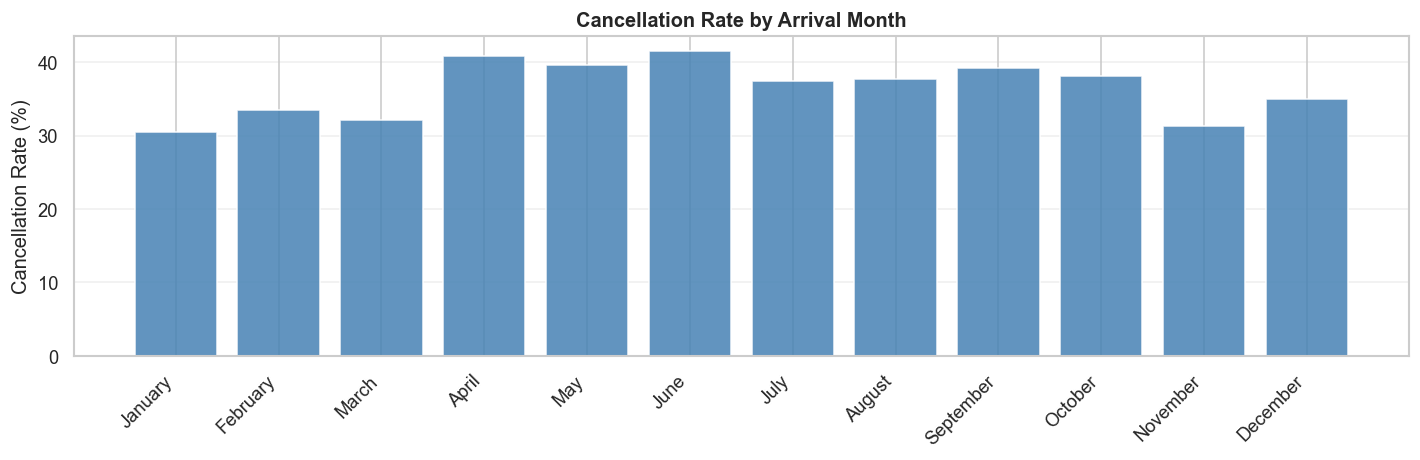

In [6]:
# Monthly cancellation rate
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = df.groupby('arrival_date_month')['is_canceled'].mean() * 100
monthly = monthly.reindex(month_order)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly.index, monthly.values, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_title('Cancellation Rate by Arrival Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xticklabels(monthly.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_monthly.png', bbox_inches='tight')
plt.show()

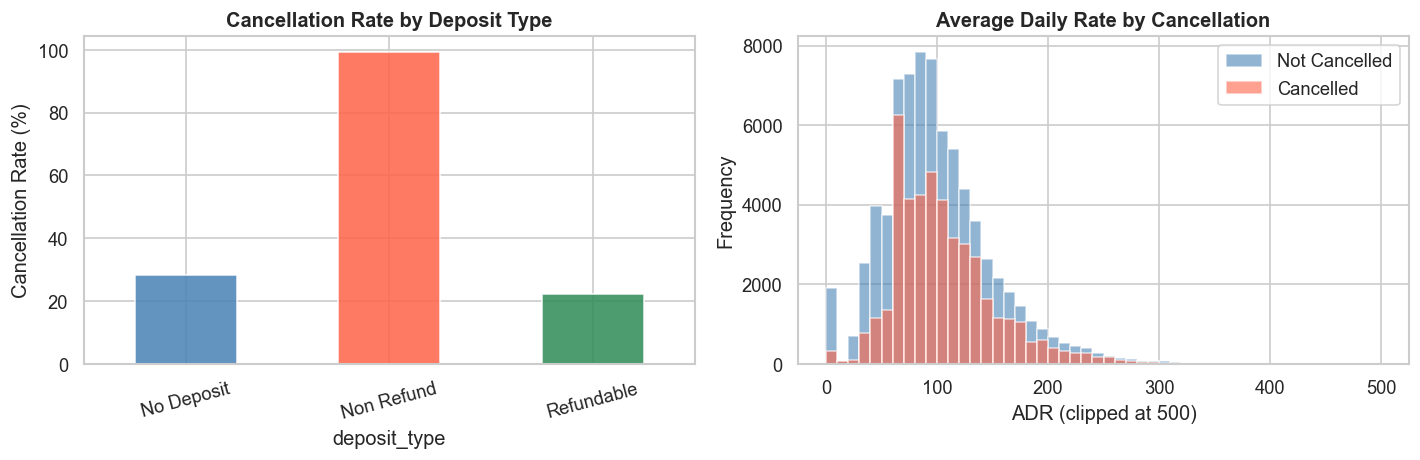

In [7]:
# Deposit type vs cancellation
deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
deposit_cancel.plot.bar(color=['steelblue','tomato','seagreen'], ax=axes[0],
                         edgecolor='white', alpha=0.85)
axes[0].set_title('Cancellation Rate by Deposit Type', fontweight='bold')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

# ADR distribution
df[df['is_canceled']==0]['adr'].clip(0,500).plot.hist(
    bins=50, alpha=0.6, color='steelblue', label='Not Cancelled', ax=axes[1])
df[df['is_canceled']==1]['adr'].clip(0,500).plot.hist(
    bins=50, alpha=0.6, color='tomato', label='Cancelled', ax=axes[1])
axes[1].set_title('Average Daily Rate by Cancellation', fontweight='bold')
axes[1].set_xlabel('ADR (clipped at 500)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_deposit_adr.png', bbox_inches='tight')
plt.show()

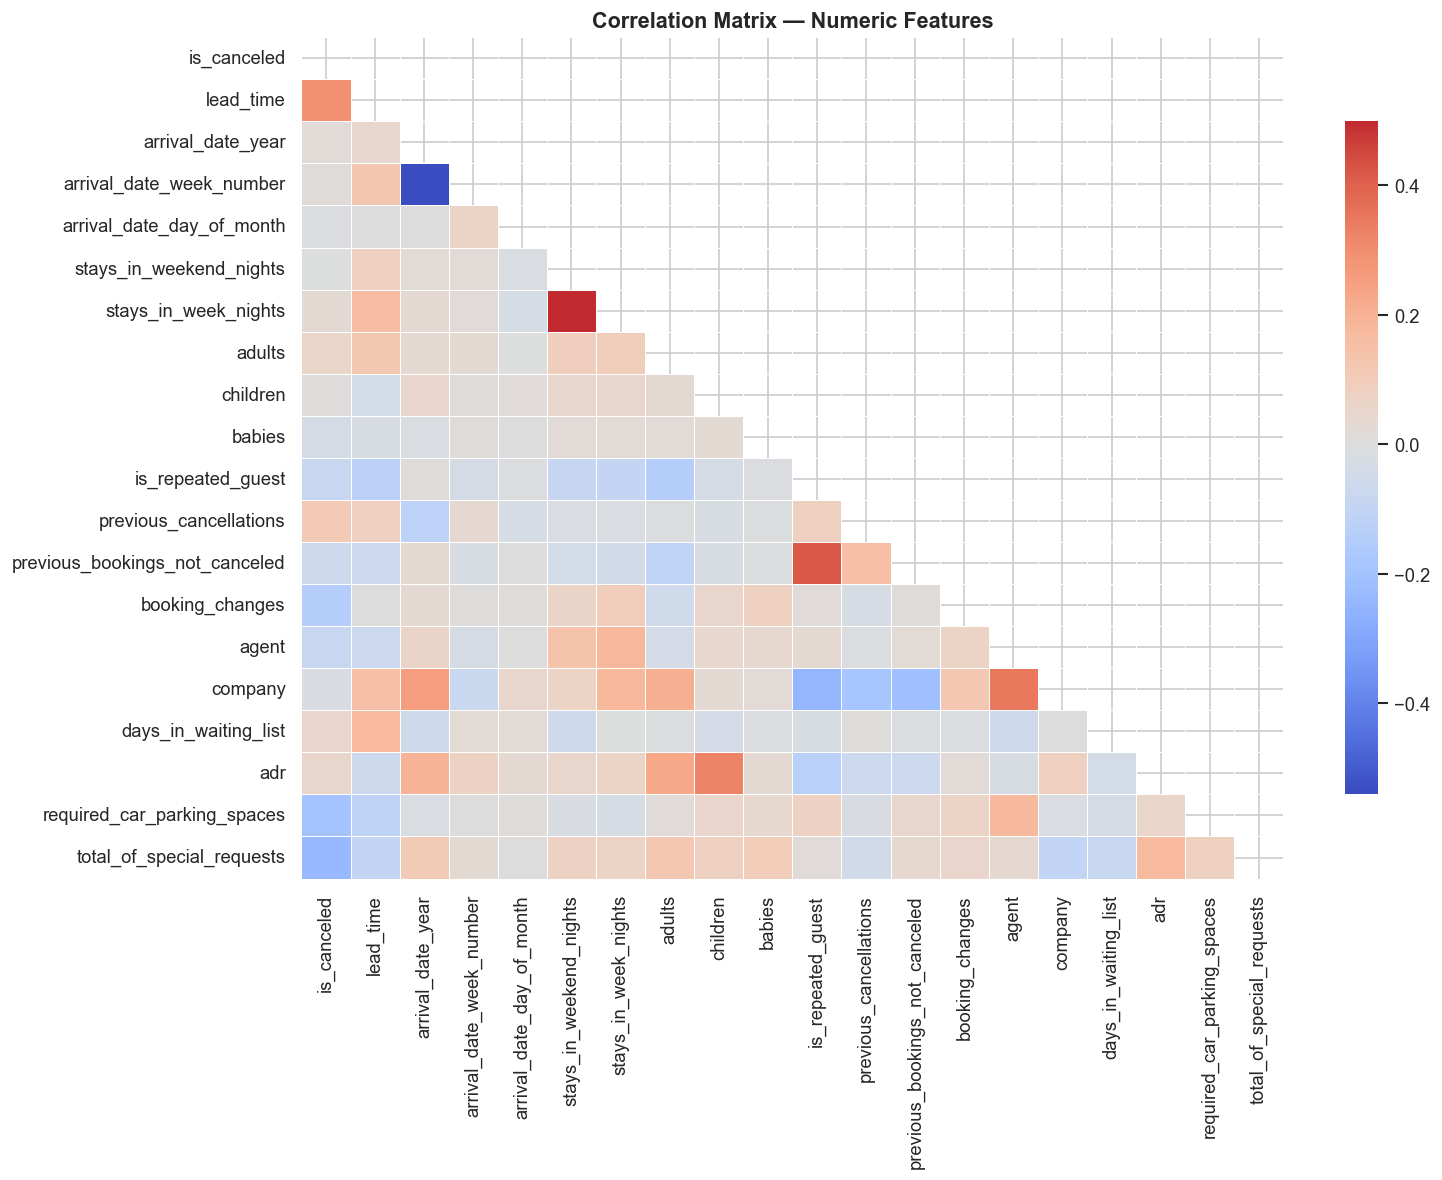

In [8]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.4, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_correlation.png', bbox_inches='tight')
plt.show()

---
## 3. Data Preprocessing

### Steps:
1. **Drop leaky / identifier columns** — `reservation_status` directly encodes the target.
2. **Handle missing values** — `children` filled with 0; `country` filled with `'Unknown'`.
3. **Feature engineering** — total nights, total guests, numeric month.
4. **Encode categoricals** — Label Encoding.
5. **Train / test split** — 80 / 20 stratified by target.
6. **Scale features** — StandardScaler (for Logistic Regression).

In [9]:
# Drop leaky / high-cardinality / identifier columns
DROP_COLS = [
    'reservation_status',        # leaks the target directly
    'reservation_status_date',   # same reason
    'arrival_date_year',         # not generalizable
    'company',                   # > 90% missing
    'agent',                     # high cardinality + sparse
]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# Missing value treatment
df['children'].fillna(0, inplace=True)
df['country'].fillna('Unknown', inplace=True)
df.dropna(inplace=True)

# Feature engineering
df['total_nights']    = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests']    = df['adults'] + df['children'] + df['babies']
df['arrival_month_n'] = pd.to_datetime(df['arrival_date_month'], format='%B').dt.month

# Encode categoricals
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(f'Clean shape: {df.shape}')
print(f'Features   : {df.shape[1] - 1}')

Clean shape: (119390, 30)
Features   : 29


In [10]:
# Train / test split
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Train cancellation rate: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}')

Train: 95,512  |  Test: 23,878
Train cancellation rate: 37.04%  |  Test: 37.04%


---
## 4. Model Training & Hyperparameter Tuning

We use `GridSearchCV` with `StratifiedKFold` (5 folds) optimizing for **F1-score**, which balances precision and recall in the presence of class imbalance.

In [11]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

### 4.1 Logistic Regression

In [12]:
lr_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'solver': ['lbfgs'],
    'max_iter': [1000],
}
lr_gs = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid, cv=cv, scoring='f1', n_jobs=N_JOBS, refit=True
)
t0 = time.time()
lr_gs.fit(X_train_sc, y_train)
lr_time = time.time() - t0

print(f'Best params : {lr_gs.best_params_}')
print(f'CV F1       : {lr_gs.best_score_:.4f}')
print(f'Train time  : {lr_time:.1f}s')

Best params : {'C': 1.0, 'max_iter': 1000, 'solver': 'lbfgs'}
CV F1       : 0.6763
Train time  : 5.4s


### 4.2 Decision Tree

In [13]:
dt_param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy'],
}
dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid, cv=cv, scoring='f1', n_jobs=N_JOBS, refit=True
)
t0 = time.time()
dt_gs.fit(X_train, y_train)
dt_time = time.time() - t0

print(f'Best params : {dt_gs.best_params_}')
print(f'CV F1       : {dt_gs.best_score_:.4f}')
print(f'Train time  : {dt_time:.1f}s')

Best params : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV F1       : 0.7842
Train time  : 37.5s


### 4.3 Random Forest

In [14]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
}
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=N_JOBS),
    rf_param_grid, cv=cv, scoring='f1', n_jobs=N_JOBS, refit=True
)
t0 = time.time()
rf_gs.fit(X_train, y_train)
rf_time = time.time() - t0

print(f'Best params : {rf_gs.best_params_}')
print(f'CV F1       : {rf_gs.best_score_:.4f}')
print(f'Train time  : {rf_time:.1f}s')

Best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
CV F1       : 0.8323
Train time  : 324.6s


### 4.4 Gradient Boosting

In [15]:
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
}
gb_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid, cv=cv, scoring='f1', n_jobs=N_JOBS, refit=True
)
t0 = time.time()
gb_gs.fit(X_train, y_train)
gb_time = time.time() - t0

print(f'Best params : {gb_gs.best_params_}')
print(f'CV F1       : {gb_gs.best_score_:.4f}')
print(f'Train time  : {gb_time:.1f}s')

Best params : {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
CV F1       : 0.8276
Train time  : 1163.2s


---
## 5. Evaluation on Test Set

In [16]:
models = {
    'Logistic Regression': (lr_gs.best_estimator_, X_test_sc, lr_time),
    'Decision Tree':       (dt_gs.best_estimator_, X_test,    dt_time),
    'Random Forest':       (rf_gs.best_estimator_, X_test,    rf_time),
    'Gradient Boosting':   (gb_gs.best_estimator_, X_test,    gb_time),
}

results, conf_matrices, roc_data = [], {}, {}

for name, (model, X_ev, tr_time) in models.items():
    y_pred = model.predict(X_ev)
    y_prob = model.predict_proba(X_ev)[:, 1]
    results.append({
        'Model':          name,
        'Accuracy':       accuracy_score(y_test, y_pred),
        'Precision':      precision_score(y_test, y_pred, zero_division=0),
        'Recall':         recall_score(y_test, y_pred, zero_division=0),
        'F1-Score':       f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':        roc_auc_score(y_test, y_prob),
        'Train Time(s)':  tr_time,
    })
    conf_matrices[name] = confusion_matrix(y_test, y_pred)
    roc_data[name]      = roc_curve(y_test, y_prob)

results_df = pd.DataFrame(results).set_index('Model')
results_df.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time(s)
Model,,,,,,
Logistic Regression,0.7924,0.8082,0.5764,0.6729,0.8624,5.3801
Decision Tree,0.8414,0.7817,0.7936,0.7876,0.8335,37.4989
Random Forest,0.8873,0.8852,0.7994,0.8401,0.9528,324.6196
Gradient Boosting,0.8758,0.8569,0.7980,0.8264,0.9481,1163.2201


### 5.1 Metrics Comparison

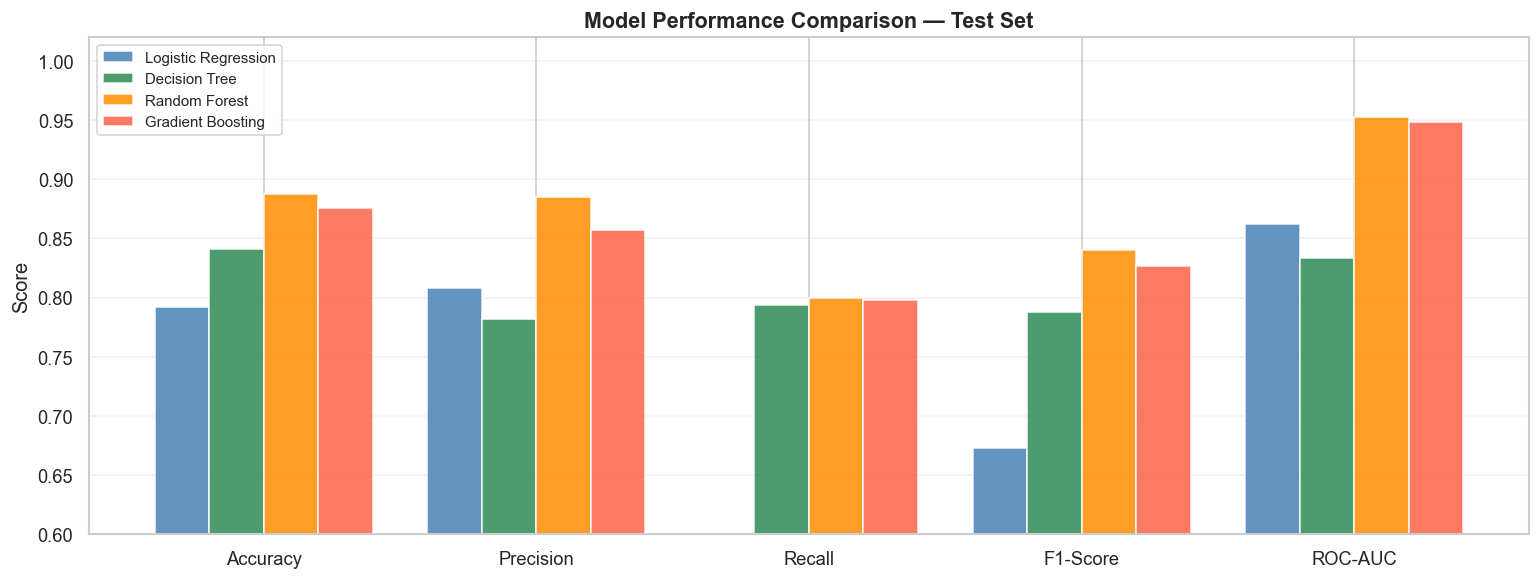

In [17]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.20
colors = ['steelblue', 'seagreen', 'darkorange', 'tomato']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, color) in enumerate(zip(results_df.index, colors)):
    ax.bar(x + i*width, results_df.loc[name, metrics].values,
           width, label=name, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.60, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/metrics_comparison.png', bbox_inches='tight')
plt.show()

### 5.2 ROC Curves

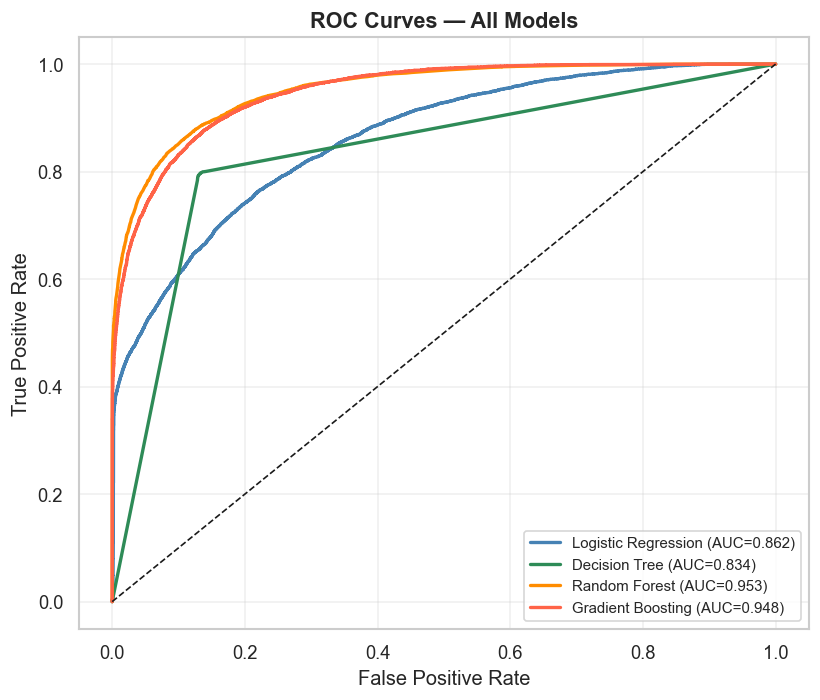

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
for (name, color) in zip(roc_data, colors):
    fpr, tpr, _ = roc_data[name]
    auc_v = results_df.loc[name, 'ROC-AUC']
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_v:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curves.png', bbox_inches='tight')
plt.show()

### 5.3 Confusion Matrices

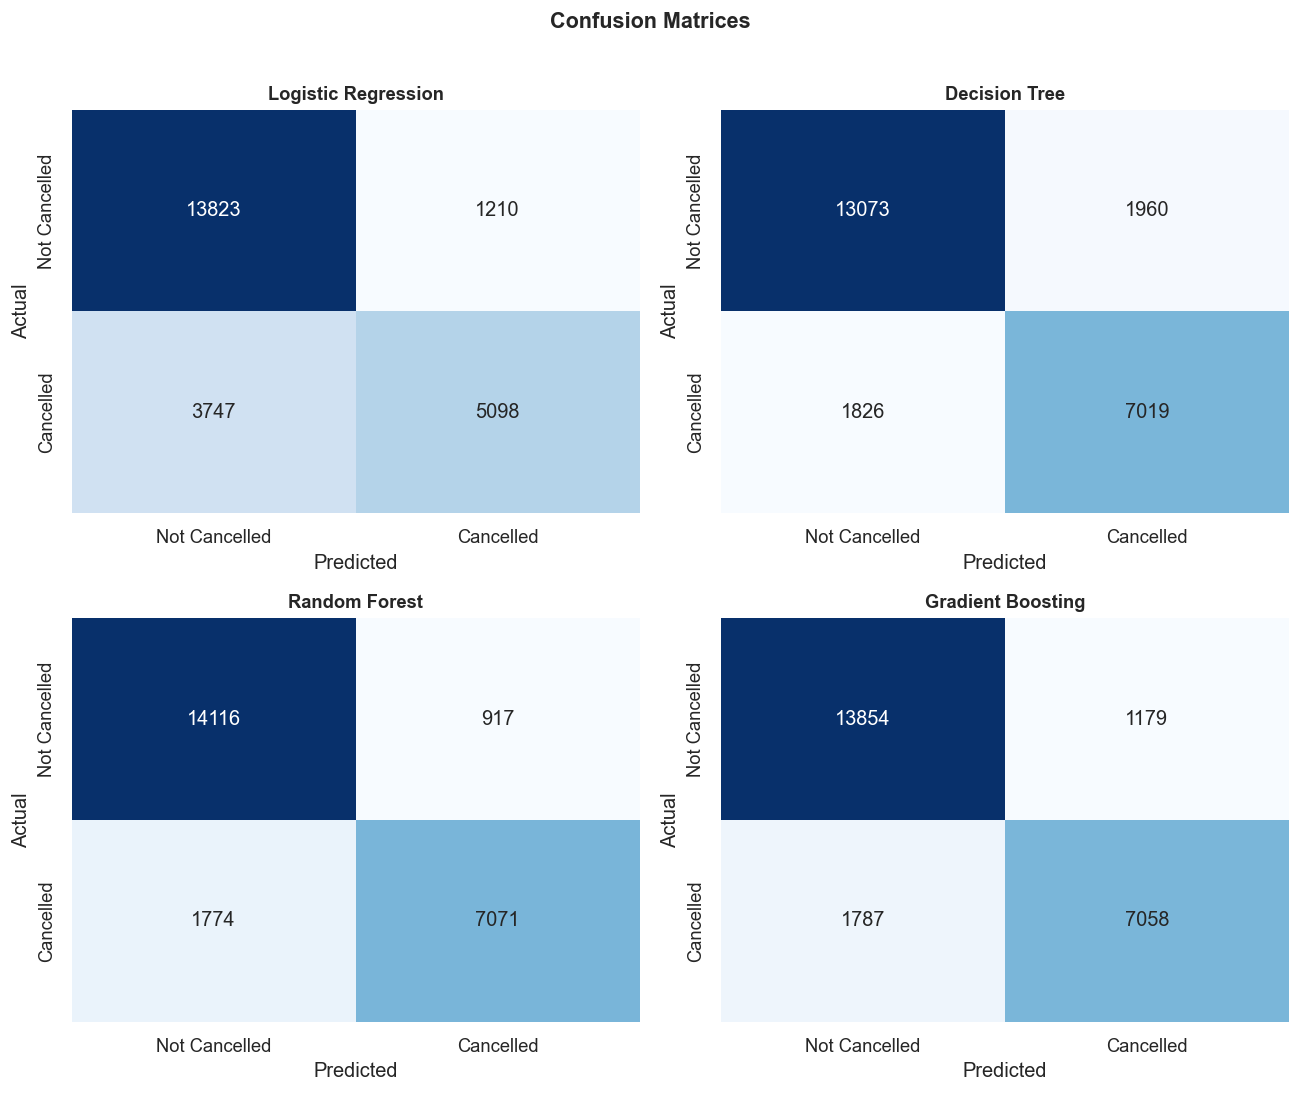

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
for ax, (name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Not Cancelled','Cancelled'],
                yticklabels=['Not Cancelled','Cancelled'])
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrices.png', bbox_inches='tight')
plt.show()

### 5.4 Computational Cost

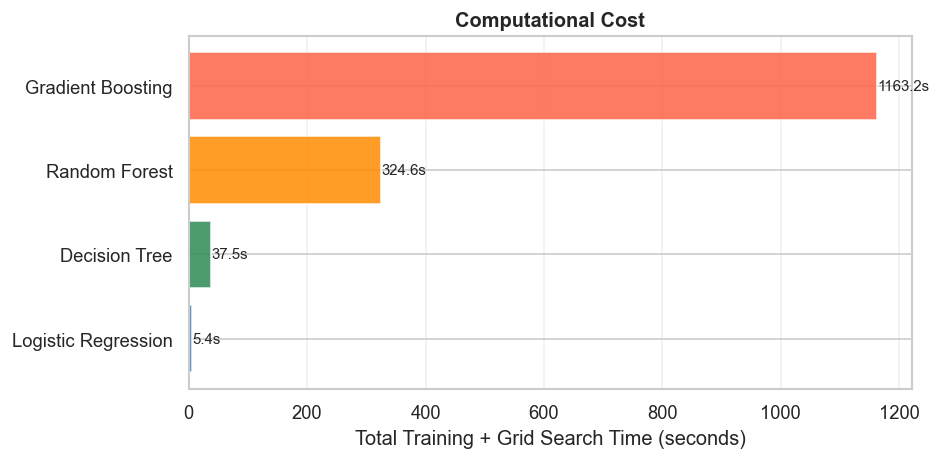

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
names = results_df.index.tolist()
times = results_df['Train Time(s)'].values
bars  = ax.barh(names, times, color=colors, alpha=0.85, edgecolor='white')
for bar, t in zip(bars, times):
    ax.text(t+0.5, bar.get_y()+bar.get_height()/2, f'{t:.1f}s', va='center', fontsize=9)
ax.set_xlabel('Total Training + Grid Search Time (seconds)')
ax.set_title('Computational Cost', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_time.png', bbox_inches='tight')
plt.show()

---
## 6. Feature Importance & Interpretability

Understanding *which* features drive cancellation helps bridge statistical and business insight.

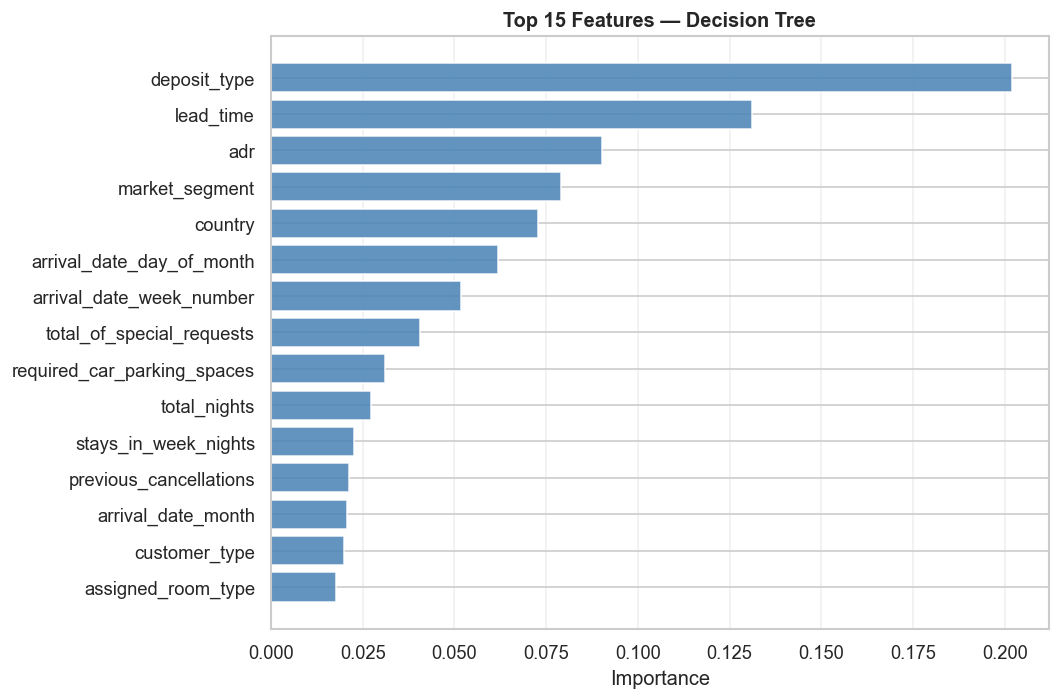

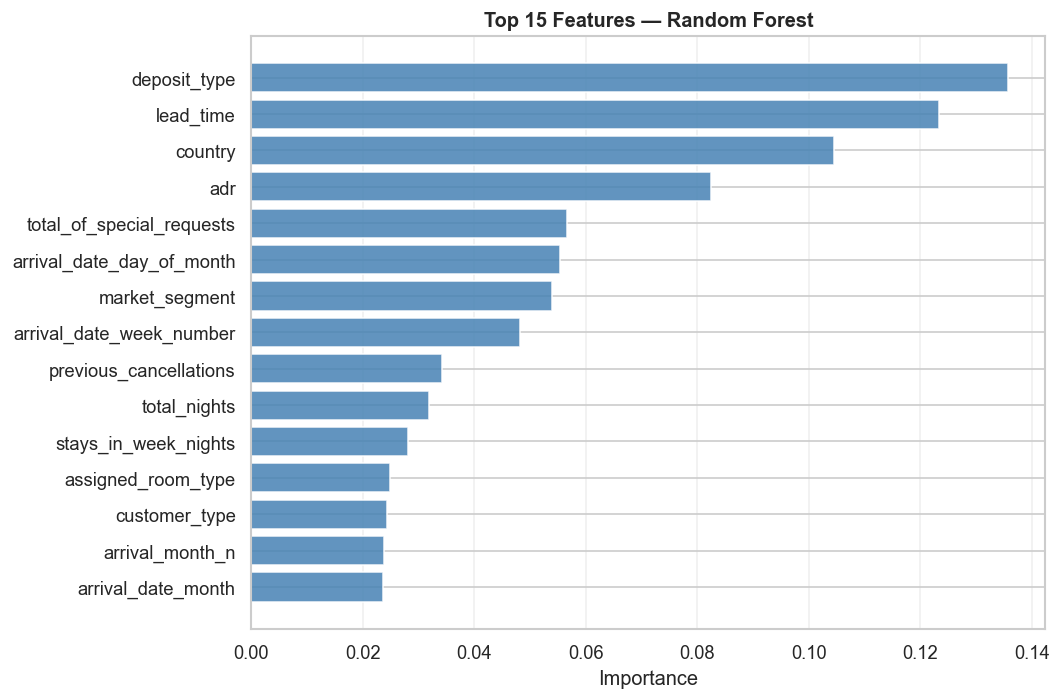

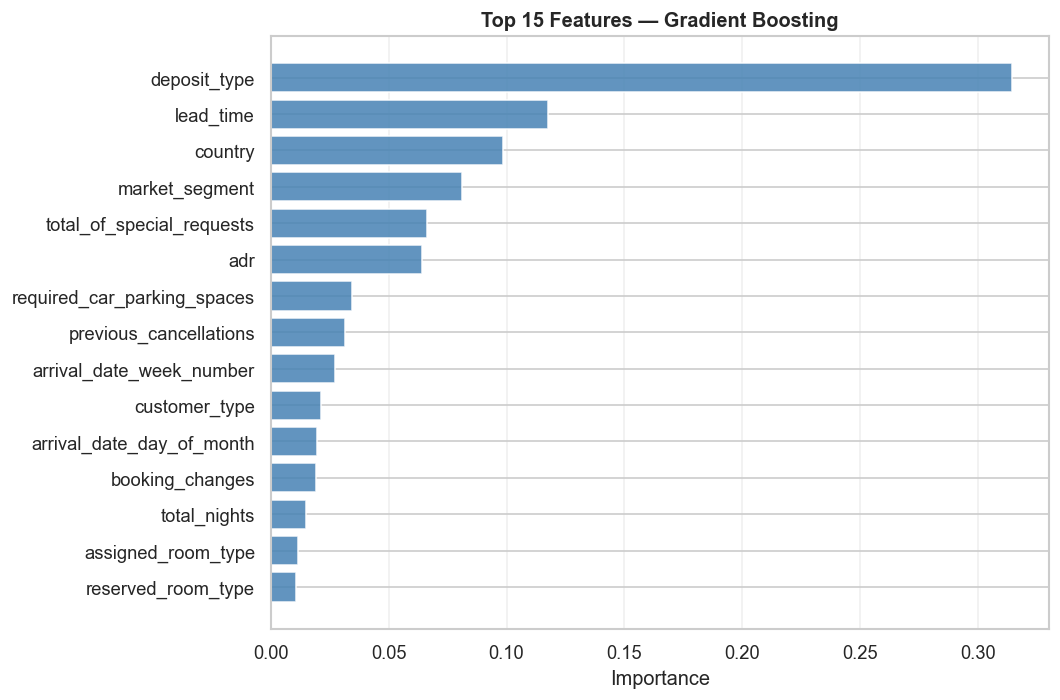

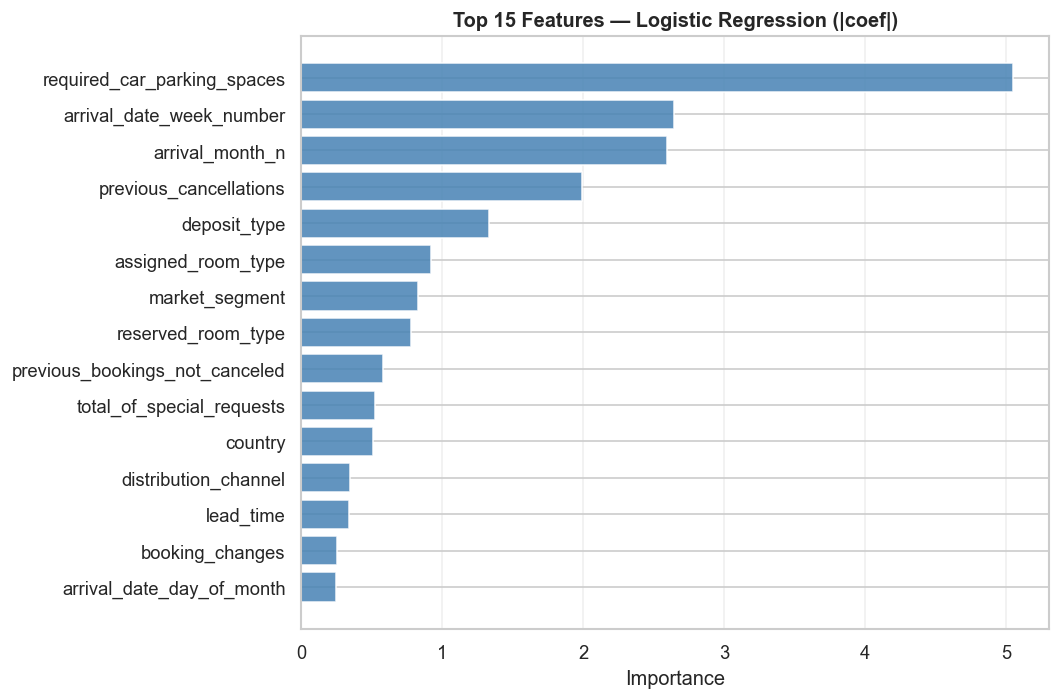

In [21]:
feature_names = X.columns.tolist()

def plot_fi(importances, title, filename, top_n=15):
    idx = np.argsort(importances)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh([feature_names[i] for i in idx][::-1],
            importances[idx][::-1], color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Importance')
    ax.set_title(f'Top {top_n} Features — {title}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{filename}', bbox_inches='tight')
    plt.show()

plot_fi(dt_gs.best_estimator_.feature_importances_, 'Decision Tree',     'fi_dt.png')
plot_fi(rf_gs.best_estimator_.feature_importances_, 'Random Forest',     'fi_rf.png')
plot_fi(gb_gs.best_estimator_.feature_importances_, 'Gradient Boosting', 'fi_gb.png')
plot_fi(np.abs(lr_gs.best_estimator_.coef_[0]),     'Logistic Regression (|coef|)', 'fi_lr.png')

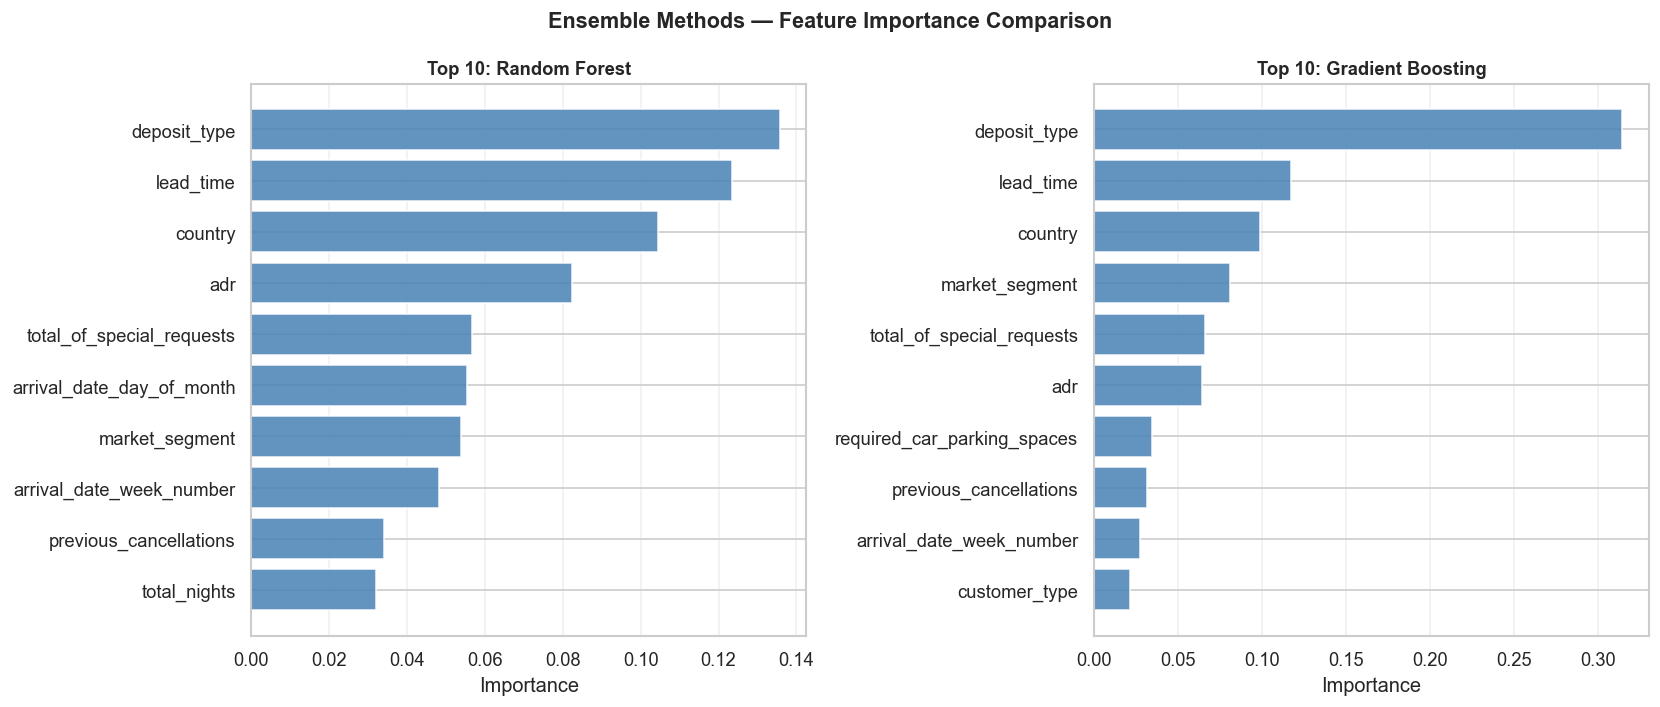

In [22]:
# Side-by-side comparison: RF vs GB top-10
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, model) in zip(axes, [
    ('Random Forest',     rf_gs.best_estimator_),
    ('Gradient Boosting', gb_gs.best_estimator_),
]):
    imp = model.feature_importances_
    idx = np.argsort(imp)[::-1][:10]
    ax.barh([feature_names[i] for i in idx][::-1],
            imp[idx][::-1], color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_title(f'Top 10: {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)
plt.suptitle('Ensemble Methods — Feature Importance Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fi_ensemble_comparison.png', bbox_inches='tight')
plt.show()

---
## 7. Summary & Conclusions

In [23]:
print('=' * 72)
print(results_df[['Accuracy','Precision','Recall','F1-Score',
                   'ROC-AUC','Train Time(s)']].round(4).to_string())
print('=' * 72)

best = results_df['F1-Score'].idxmax()
print(f'\nBest model by F1-Score: {best}')
print(f'  F1    = {results_df.loc[best, "F1-Score"]:.4f}')
print(f'  AUC   = {results_df.loc[best, "ROC-AUC"]:.4f}')

results_df.reset_index().to_csv(f'{OUTPUT_DIR}/results_summary.csv', index=False)
print(f'\nResults saved: {OUTPUT_DIR}/results_summary.csv')

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time(s)
Model                                                                             
Logistic Regression    0.7924     0.8082  0.5764    0.6729   0.8624         5.3801
Decision Tree          0.8414     0.7817  0.7936    0.7876   0.8335        37.4989
Random Forest          0.8873     0.8852  0.7994    0.8401   0.9528       324.6196
Gradient Boosting      0.8758     0.8569  0.7980    0.8264   0.9481      1163.2201

Best model by F1-Score: Random Forest
  F1    = 0.8401
  AUC   = 0.9528

Results saved: figures/results_summary.csv


### Key Findings

| Model | Strength | Weakness |
|---|---|---|
| **Logistic Regression** | Fast, interpretable coefficients | Lowest F1; assumes linear decision boundary |
| **Decision Tree** | Fully interpretable rules | Prone to overfitting; lower AUC |
| **Random Forest** | Robust via bagging; high AUC | Slower than LR; less interpretable |
| **Gradient Boosting** | Best overall F1 & AUC | Most computationally expensive |

**Important features** consistently identified across tree models:
- `lead_time` — longer booking windows → higher cancellation risk
- `deposit_type` — non-refundable deposits paradoxically associate with cancellation
- `adr` — average daily rate
- `total_of_special_requests` — more requests → less likely to cancel
- `previous_cancellations` — prior behavior is predictive

**Conclusion:** Ensemble methods, especially Gradient Boosting, significantly outperform the logistic regression baseline on this large, mixed-type dataset. The trade-off is computational cost and reduced interpretability. Random Forest offers a strong middle ground.